In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
recipes = pd.read_csv('../data/recipes_cleaned.csv')
print('Shape:', recipes.shape)

Shape: (83782, 20)


Hypothesis Testing:

Null hypothesis (H0):
There is no difference in average rating between short and long cooking-time recipes. Any observed difference is due to random chance.

Alternative hypothesis (H1):
There is a difference in average rating between short and long cooking-time recipes.

Define short recipes: minutes < 30
Define long recipes: minutes > 60

In [25]:
recipes['minutes'].describe()

count    8.378200e+04
mean     1.150309e+02
std      3.990871e+03
min      0.000000e+00
25%      2.000000e+01
50%      3.500000e+01
75%      6.500000e+01
max      1.051200e+06
Name: minutes, dtype: float64

In [26]:
# drop null avg_rating
recipes_clean = recipes[['minutes','avg_rating']].dropna()

# divide long and short recipes
short_recipe = recipes_clean[recipes_clean['minutes'] < 30]
long_recipe = recipes_clean[recipes_clean['minutes'] > 60]

print("Short recipes:", len(short_recipe))
print("Long recipes:", len(long_recipe))

Short recipes: 29563
Long recipes: 20184


In [27]:
# Observed Statistic
short_mean = short_recipe['avg_rating'].mean()
long_mean = long_recipe['avg_rating'].mean()

obs_diff = short_mean - long_mean

print("Mean rating (short):", short_mean)
print("Mean rating (long):", long_mean)
print("Observed difference (short - long):", obs_diff)


Mean rating (short): 4.6493067328610715
Mean rating (long): 4.613451206762783
Observed difference (short - long): 0.03585552609828824


In [28]:
# Permutation Test（p-value）
combined = pd.concat([short_recipe, long_recipe]).copy()
combined['group'] = combined['minutes'] < 30

n_perm = 2000
perm_diffs = []

for _ in range(n_perm):
    shuffled = combined['group'].sample(frac=1, replace=False).values
    
    perm_short = combined[shuffled]['avg_rating']
    perm_long = combined[~shuffled]['avg_rating']
    
    diff = perm_short.mean() - perm_long.mean()
    perm_diffs.append(diff)
    
perm_diffs = np.array(perm_diffs)

p_value = np.mean(np.abs(perm_diffs) >= abs(obs_diff))
print("p_value:", p_value)

p_value: 0.0


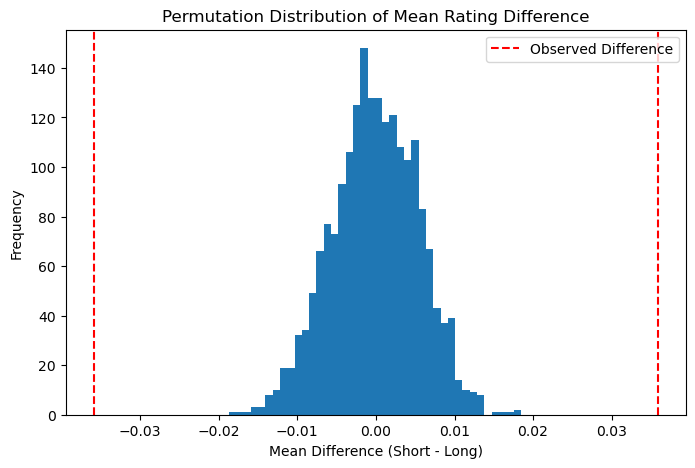

In [29]:
plt.figure(figsize=(8,5))
plt.hist(perm_diffs, bins=40)
plt.axvline(obs_diff, color='red', linestyle='--', label='Observed Difference')
plt.axvline(-obs_diff, color='red', linestyle='--')
plt.title("Permutation Distribution of Mean Rating Difference")
plt.xlabel("Mean Difference (Short - Long)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

Conclusion：
1. Observed mean difference (short - long) = 0.036
2. significance level: 0.05, p_value = 0.0
p-value < 0.0005 (0 out of 2000 permutations exceeded observed difference)
reject null hypothesis at α = 0.05
3. short recipes (minutes < 30) have slightly higher average ratings than long recipes (minutes > 60)
4. Key insight:
cooking time is statistically related to average recipe rating.

Step 5: Predict average recipe rating (regression)

Our prediction task is to predict the average rating of a recipe using its available features. This is a regression problem, since the response variable (average rating) is continuous.

We chose average rating as the response variable because it reflects overall user satisfaction and is an important indicator of recipe quality.

At the time of prediction, we assume that recipe metadata such as cooking time, number of steps, nutrition information, and ingredient-related features are available, but user ratings are not yet known.

We evaluate model performance using RMSE because it measures prediction error in the same scale as ratings.

step 6: Baseline Model

In [32]:
# features(numerical): minutes, n_steps, n_ingredients, calories
# model: Ridge Regression
# Metircs: RMSE(measures prediction error in the same scale as ratings and penalizes larger errors more heavily than MAE.)
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error

# create X and y
features = ['minutes', 'n_steps', 'n_ingredients', 'calories']
recipes_clean2 = recipes[features + ['avg_rating']].dropna()
X = recipes_clean2[features]
y = recipes_clean2['avg_rating']

# split train and test data
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(64938, 4) (16235, 4) (64938,) (16235,)


In [33]:
# train the model
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

baseline_model = Pipeline([
    ("scaler",StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

baseline_model.fit(X_train, y_train)
y_pred = baseline_model.predict(X_test)

rmse = root_mean_squared_error(y_test, y_pred)
print("Baseline RMSE:", rmse)

Baseline RMSE: 0.6359861519564834


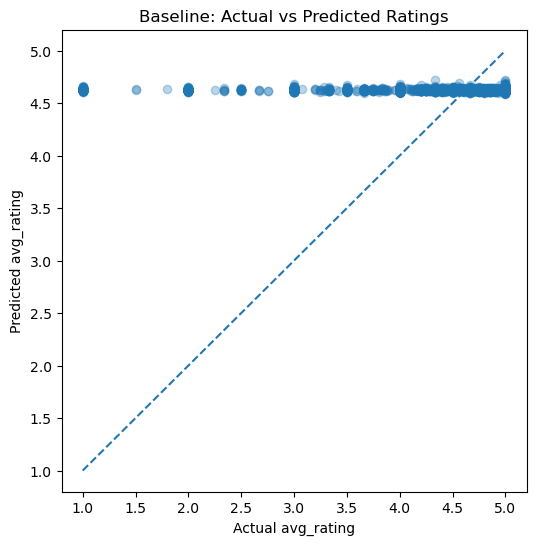

In [34]:
# Baseline Model Visualization
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual avg_rating")
plt.ylabel("Predicted avg_rating")
plt.title("Baseline: Actual vs Predicted Ratings")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.show()

Conclusion:
Our baseline model is a Ridge regression using four numerical features (minutes, n_steps, n_ingredients, calories). We evaluate with RMSE. The baseline RMSE is 0.636, which means our predictions are off by about 0.64 rating points on average.

Most predictions cluster around the mean (~4.6), indicating that the baseline model tends to predict the average rating and struggles to capture differences across recipes.